In [6]:
# ==============================
# 1. Import Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# ==============================
# 2. Read Dataset
# ==============================

from os import read
from google.colab import drive
drive.mount('/content/drive')

modeling = "/content/drive/MyDrive/Colab Notebooks/Initial_Modeling_Dataset.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# ==============================
# 3. Create Tenure Bands
# ==============================

def tenure_band(x):
    if x <= 2:
        return "0-2 years"
    elif x <= 5:
        return "3-5 years"
    elif x <= 10:
        return "6-10 years"
    else:
        return "10+ years"

df["tenure_band"] = df["time_spend_company"].apply(tenure_band)

In [14]:
# ==============================
# 4. Attrition Rate by Tenure
# ==============================

attrition_summary = df.groupby("tenure_band").agg(
    employees=("attrition_flag","count"),
    leavers=("attrition_flag","sum")
).reset_index()

attrition_summary["attrition_rate"] = attrition_summary["leavers"] / attrition_summary["employees"]

print(attrition_summary)


  tenure_band  employees  leavers  attrition_rate
0   0-2 years       3244       53        0.016338
1   3-5 years      10473     3309        0.315955
2  6-10 years       1282      209        0.163027


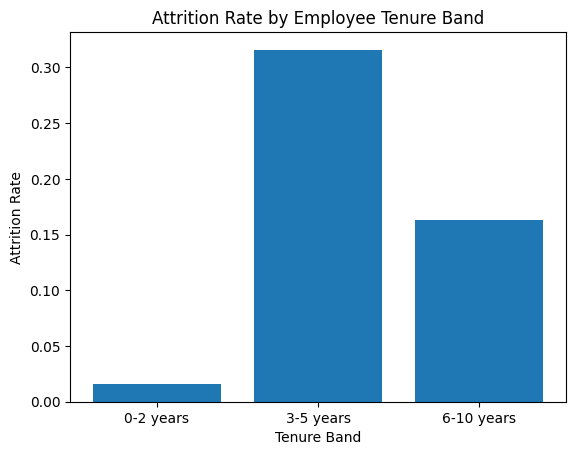

In [15]:
# ==============================
# 5. Attrition Rate by Tenure Chart
# ==============================

plt.figure()
plt.bar(attrition_summary["tenure_band"], attrition_summary["attrition_rate"])
plt.xlabel("Tenure Band")
plt.ylabel("Attrition Rate")
plt.title("Attrition Rate by Employee Tenure Band")
plt.show()



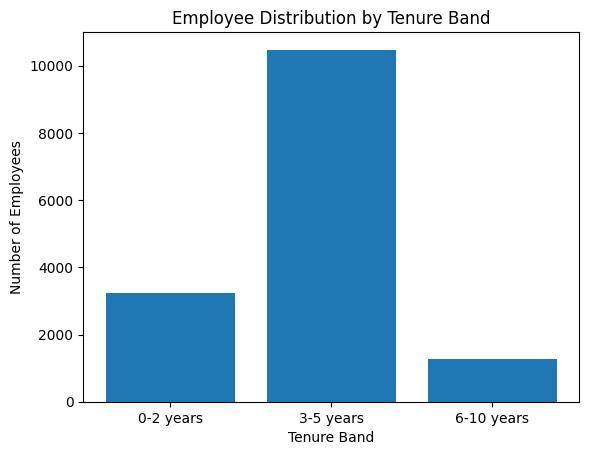

In [16]:
# ==============================
# 6. Workforce Distribution by Tenure
# ==============================

plt.figure()
plt.bar(attrition_summary["tenure_band"], attrition_summary["employees"])
plt.xlabel("Tenure Band")
plt.ylabel("Number of Employees")
plt.title("Employee Distribution by Tenure Band")
plt.show()


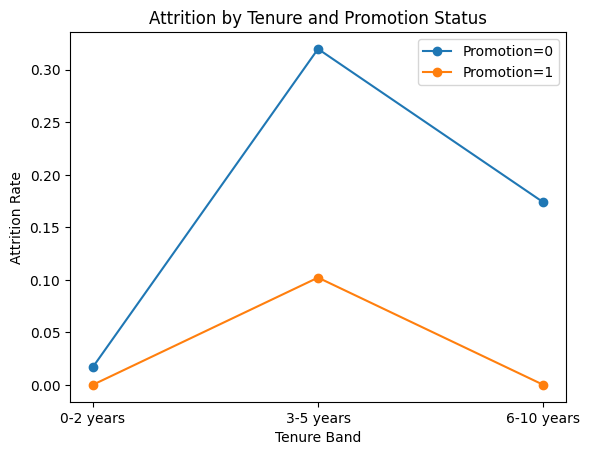

In [17]:
# ==============================
# 7. Attrition by Tenure & Promotion
# ==============================

promo_attrition = df.groupby(["tenure_band","promotion_last_5years"])["attrition_flag"].mean().reset_index()

plt.figure()

for key, grp in promo_attrition.groupby("promotion_last_5years"):
    plt.plot(grp["tenure_band"], grp["attrition_flag"], marker="o", label=f"Promotion={key}")

plt.xlabel("Tenure Band")
plt.ylabel("Attrition Rate")
plt.title("Attrition by Tenure and Promotion Status")
plt.legend()
plt.show()



/tmp/ipykernel_3222/371424065.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sat_attrition = df.groupby("satisfaction_bin")["attrition_flag"].mean().reset_index()


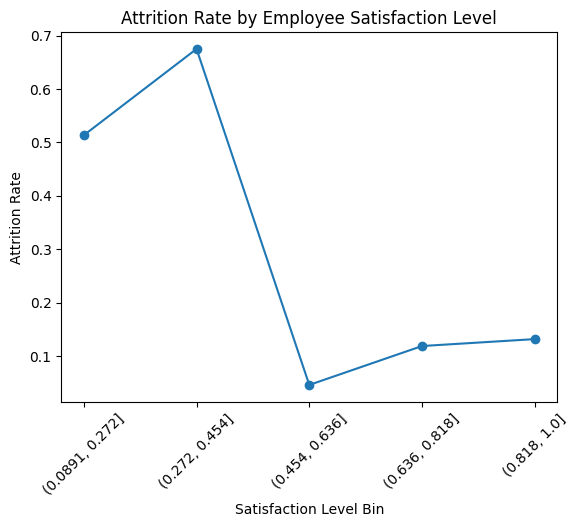

In [18]:
# ==============================
# 8. Attrition vs Satisfaction
# ==============================

df["satisfaction_bin"] = pd.cut(df["satisfaction_level"], bins=5)

sat_attrition = df.groupby("satisfaction_bin")["attrition_flag"].mean().reset_index()

plt.figure()
plt.plot(sat_attrition["satisfaction_bin"].astype(str), sat_attrition["attrition_flag"], marker="o")
plt.xlabel("Satisfaction Level Bin")
plt.ylabel("Attrition Rate")
plt.title("Attrition Rate by Employee Satisfaction Level")
plt.xticks(rotation=45)
plt.show()


/tmp/ipykernel_3222/2482283487.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hours_attrition = df.groupby("hours_bin")["attrition_flag"].mean().reset_index()


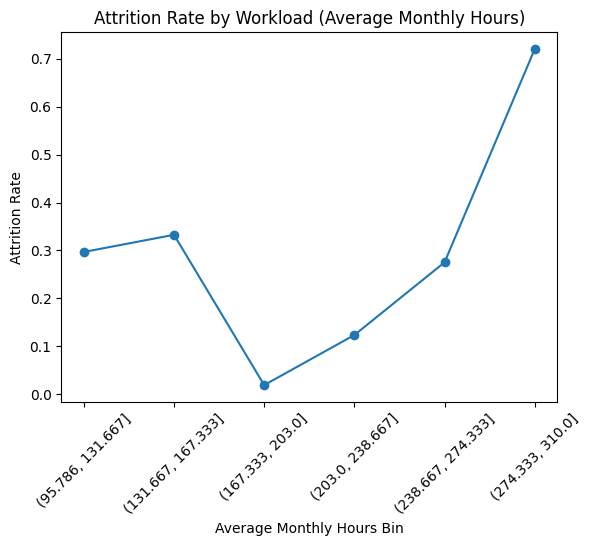

In [19]:
# ==============================
# 9. Attrition vs Workload
# ==============================

df["hours_bin"] = pd.cut(df["average_montly_hours"], bins=6)

hours_attrition = df.groupby("hours_bin")["attrition_flag"].mean().reset_index()

plt.figure()
plt.plot(hours_attrition["hours_bin"].astype(str), hours_attrition["attrition_flag"], marker="o")
plt.xlabel("Average Monthly Hours Bin")
plt.ylabel("Attrition Rate")
plt.title("Attrition Rate by Workload (Average Monthly Hours)")
plt.xticks(rotation=45)
plt.show()


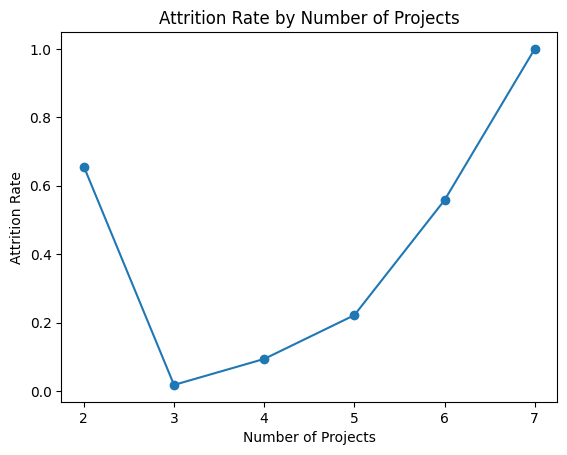

In [20]:
# ==============================
# 10. Attrition vs Number of Projects
# ==============================

proj_attrition = df.groupby("number_project")["attrition_flag"].mean().reset_index()

plt.figure()
plt.plot(proj_attrition["number_project"], proj_attrition["attrition_flag"], marker="o")
plt.xlabel("Number of Projects")
plt.ylabel("Attrition Rate")
plt.title("Attrition Rate by Number of Projects")
plt.show()


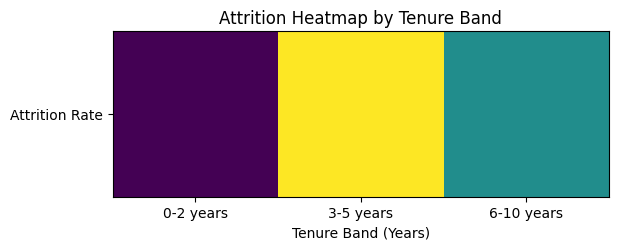

In [21]:
# ==============================
# 11. Heatmap: Tenure vs Attrition
# ==============================

heat_data = df.groupby("tenure_band")["attrition_flag"].mean()

matrix = np.array([heat_data.values])

plt.figure()
plt.imshow(matrix)
plt.yticks([0], ["Attrition Rate"])
plt.xticks(range(len(heat_data.index)), heat_data.index)
plt.xlabel("Tenure Band (Years)")
plt.title("Attrition Heatmap by Tenure Band")
plt.show()